# Gaussian Mixture Model (GMM)

- GMM: fits K Gaussian distributions to the data using the EM algorithm
- Unlike K-Means, assigns soft probabilities instead of hard cluster labels
- Can model elliptical clusters of any shape/orientation, not just round blobs
- Dataset: Mall_Customers.csv (same as K-Means and Hierarchical, for comparison)
[https://www.kaggle.com/code/habibamahmoud21/mall-customers-dataset](https://)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

In [2]:
df = pd.read_csv('/content/Mall_Customers.csv')
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


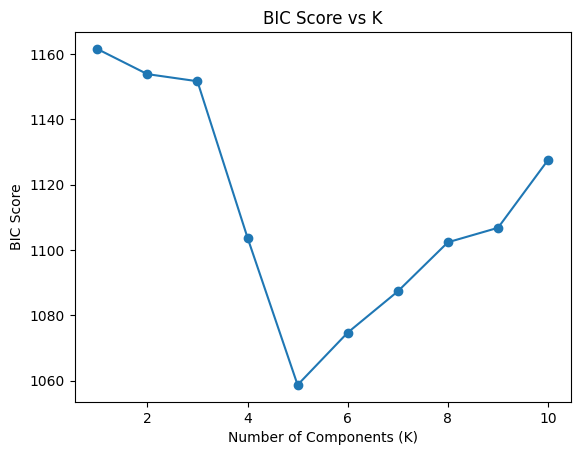

Best K by BIC: 5


In [4]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

sc = StandardScaler()
X_scaled = sc.fit_transform(X)

bic_scores = []
k_range = range(1, 11)

for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))

plt.plot(k_range, bic_scores, marker="o")
plt.xlabel("Number of Components (K)")
plt.ylabel("BIC Score")
plt.title("BIC Score vs K")
plt.show()

best_k = k_range[bic_scores.index(min(bic_scores))]
print("Best K by BIC:", best_k)

In [5]:
model = GaussianMixture(n_components=5, random_state=42)
model.fit(X_scaled)

clusters = model.predict(X_scaled)
probs = model.predict_proba(X_scaled)

df["Cluster"] = clusters
print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


   Cluster_0  Cluster_1  Cluster_2  Cluster_3  Cluster_4
0      0.000        0.0      0.001        0.0      0.999
1      0.000        0.0      1.000        0.0      0.000
2      0.000        0.0      0.000        0.0      1.000
3      0.000        0.0      1.000        0.0      0.000
4      0.000        0.0      0.002        0.0      0.998
5      0.000        0.0      1.000        0.0      0.000
6      0.000        0.0      0.000        0.0      1.000
7      0.000        0.0      1.000        0.0      0.000
8      0.000        0.0      0.000        0.0      1.000
9      0.001        0.0      0.998        0.0      0.000


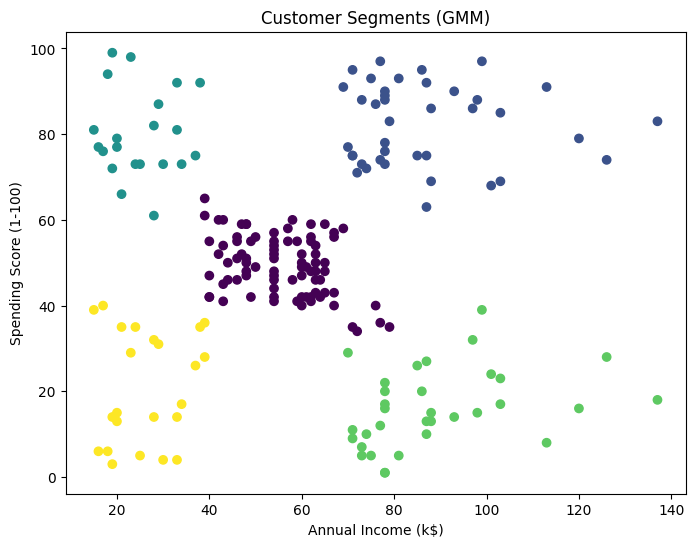

In [6]:
prob_df = pd.DataFrame(probs.round(3), columns=[f"Cluster_{i}" for i in range(5)])
print(prob_df.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(X["Annual Income (k$)"], X["Spending Score (1-100)"], c=clusters, cmap="viridis")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments (GMM)")
plt.show()

## Conclusion
- BIC score found the optimal K — the point where adding more Gaussians stops improving the model enough to justify the complexity
- GMM assigned soft probabilities to each customer, so boundary customers between segments have split probabilities rather than forced labels
- Compared to K-Means (hard labels, round clusters) and Hierarchical (merge-based, no probabilities), GMM gives the most nuanced view of which cluster each customer truly belongs to
- All three methods agreed on roughly 5 segments for this dataset, which gives confidence that 5 is a genuine structure in the data